In [5]:
import numpy as np
import pandas as pd

from smooth import ADAM

df = pd.read_csv("../data/etsx_data.csv")

y = df["y"]
X = df[["x1", "x2"]]

model = ADAM(model="AAN", regressors="use", h=5, holdout=True, smoother="global")
model.fit(y, X)


print(model.summary())

model.predict(5, X.tail(5))


Time elapsed: 0.04 seconds
Model estimated using ADAM() function: ETSX(AAN)
With backcasting initialisation
Distribution assumed in the model: Normal
Loss function type: likelihood; Loss function value: 157.4708
Persistence vector g:
 alpha   beta
0.0223 0.0000
Sample size: 115
Number of estimated parameters: 5
Number of degrees of freedom: 110
Information criteria:
      AIC      AICc       BIC      BICc
 324.9415  325.4920  338.6662  339.9721


          mean
115   9.499318
116   6.680249
117  14.756861
118   6.690754
119  11.260099

Time elapsed: 0.30 seconds
Model estimated using ADAM() function: ETS(MAM)
With backcasting initialisation
Distribution assumed in the model: Gamma
Loss function type: likelihood; Loss function value: 723.9713
Persistence vector g:
 alpha   beta  gamma
0.0065 0.0000 0.0000
Sample size: 98
Number of estimated parameters: 4
Number of degrees of freedom: 94
Information criteria:
      AIC      AICc       BIC      BICc
1455.9426 1456.3727 1466.2824 1467.2685

Forecast errors:
ME: -581.2499; MAE: 604.2299; RMSE: 710.7395
sCE: -149.9995%; Asymmetry: -2.5%; sMAE: 8.6628%; sMSE: 1.0383%
MASE: 0.2654; RMSSE: 0.2453; rMAE: 0.2555; rRMSE: 0.2164


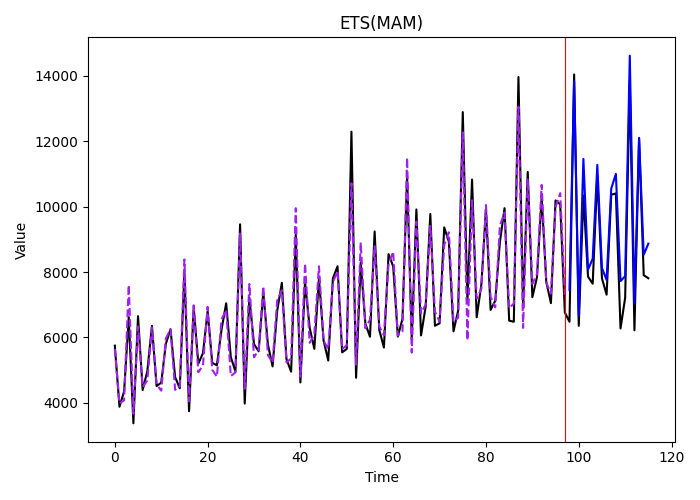

In [1]:
from fcompdata import M3
from smooth import ADAM

series = M3[2568]

# Fit model
model = ADAM(model="ZXZ", lags=[1,series.period],
            #  ar_order=[1,1], i_order=[1,1], ma_order=[1,2],
             initial="backcasting",
             nlopt_kargs={"print_level": 0,
                          "maxeval": 0},
             holdout=True, h=18)

model.fit(series.x)

print(model)

model.plot(7)

In [2]:
from fcompdata import M3
from smooth import AutoADAM

series = M3[2568]

# Fit model
model = AutoADAM(model="ANN", lags=[1,series.period],
                 orders={"ar": [3,3], "i": [2,2], "ma": [3,3]},
                 arima_select=True,
                 initial="backcasting",
                 nlopt_kargs={"print_level": 0,
                              "maxeval": 1})

model.fit(series.x)

print(model)

Time elapsed: 3.69 seconds
Model estimated using ADAM() function: ETS(ANN)+SARIMA(3,0,0)[1](0,1,1)[12] with drift
With backcasting initialisation
Distribution assumed in the model: Log-Normal
Loss function type: likelihood; Loss function value: 872.0257
Intercept/Drift value: 77.6781
Persistence vector g:
 alpha
0.0047
ARMA parameters of the model:
             Lag 1
AR(1)       0.0339
AR(2)       0.1965
AR(3)       0.4795
            Lag 12
MA(1)      -0.1571
Sample size: 116
Number of estimated parameters: 7
Number of degrees of freedom: 109
Information criteria:
      AIC      AICc       BIC      BICc
1758.0513 1759.0883 1777.3264 1779.7913
